# Experiment 1A: ISI — Hidden-Layer Perturbation (Learnable Tau)

## Overview

This notebook implements Experiment 1A from the "Beyond Beyond Rate" project.
We train an SNN (with learnable tau, **no delays**) on the ISI synthetic task
using a **train-at-f / evaluate-at-f** protocol: for each perturbation level
*f* we train a fresh model with hidden-layer spike perturbation applied during
training, then evaluate that model at the same *f*.

**Key idea:** A fraction *f* of each hidden neuron's spikes are randomly
relocated (preserving spike count). Because the perturbation is non-
differentiable, we use a straight-through estimator so fc1 and the PSP filter
still receive gradients during training.

| Property | Value |
|---|---|
| Architecture | Input (10) → Hidden (100, SRMALPHA, learnable tau) → Output (2) |
| Training perturbation | Hidden-layer spikes, f matches evaluation |
| f values | {0, 0.2, 0.4, 0.6, 0.8, 1.0} |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

## 1. Imports and Setup

In [16]:
import os
import sys
import json
import random
import pickle
from typing import Optional

import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
#sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors. We use SRMALPHA neurons
with a 1 ms sampling period and 1000 ms (1 s) sample duration, matching
the ISI dataset time steps.

In [17]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 48

# --- Hidden-perturbation sweep ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3  # repeated evaluations per f to get error bars

## 3. Load ISI Dataset

Load the ISI spike-train dataset from the local HDF5 file.
Each sample has shape `(num_neurons, T)` with binary spike values.

In [18]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]  # (N, num_neurons, T)
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Network config: 10 input neurons, 2 classes


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [19]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    # rank[b, c, t] = position of t in the per-(b,c) ascending sort of `key`.
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move  # (B, C, T)

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask  # everything except positions we are keeping
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [20]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple[float, float], total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and return train / val / test DataLoaders (no perturbation)."""
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx = get_split_indices(VAL_RANGE, len(X))
    test_idx = get_split_indices(TEST_RANGE, len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a learnable PSP filter. The forward
pass accepts an `f` argument; when `f > 0`, hidden spikes are perturbed and
wrapped with a straight-through estimator so gradients flow back unchanged.

```
Input → [fc1 + PSP + spike] → (hidden spikes) → [perturb @ f] → [fc2 + PSP + spike] → Output
```

In [21]:
class ISINetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable tau (PSP filter).

    The forward pass optionally perturbs hidden-layer spikes at level *f*.
    Perturbation is wrapped in a straight-through estimator so that fc1 and
    the PSP filter still receive gradients during training.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

    def _apply_perturbation(self, hidden_spikes: torch.Tensor, f: float) -> torch.Tensor:
        """Apply hidden-spike perturbation with a straight-through estimator.

        Forward value uses the perturbed spikes; backward gradient flows as if
        no perturbation had been applied.
        """
        if f <= 0:
            return hidden_spikes
        perturbed = perturb_hidden_batch(hidden_spikes, f)
        return hidden_spikes + (perturbed - hidden_spikes).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass. If f > 0, perturb hidden spikes (STE in training)."""
        x = self._prepare_input(x)
        hidden_spikes = self._first_layer(x)
        hidden_spikes = self._apply_perturbation(hidden_spikes, f)
        return self._second_layer(hidden_spikes)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Alias kept for backward compatibility; identical to ``forward``."""
        return self.forward(x, f=f)

## 7. Training Loop

Train the model with hidden-layer perturbation at level *f* applied on every
forward pass (training and validation). The straight-through estimator inside
the network keeps gradients flowing through fc1 and the PSP filter.

In [22]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
    f: float = 0.0,
) -> tuple[ISINetwork, dict]:
    """Train the ISINetwork with hidden perturbation level *f*.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        epochs: Number of training epochs.
        lr: Learning rate.
        seed: Random seed for reproducibility.
        f: Hidden-layer perturbation fraction applied during training.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISINetwork(num_neurons, num_classes, hidden_units).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[300], gamma=0.5)

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Training (f={f})") as pbar:
        for epoch in range(epochs):
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch, f=f)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()

                    outputs = net(x_batch, f=f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the hidden layer and
the spike output is perturbed before being fed to the second layer.

In [23]:
def test_with_hidden_perturbation(
    net: ISINetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained ISINetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to hidden spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    accuracy = correct / total
    return accuracy


def run_hidden_perturbation_sweep(
    net: ISINetwork,
    test_loader: DataLoader,
    f_values: list[float],
    num_repeats: int = 3,
) -> dict[float, dict]:
    """Sweep over perturbation levels and collect accuracy statistics.

    Each *f* is evaluated *num_repeats* times (different random seeds)
    to obtain mean and std.

    Args:
        net: Trained ISINetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per f.

    Returns:
        Dict mapping each f to {"mean", "std", "values"}.
    """
    results: dict[float, dict] = {}

    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results[f] = {"mean": mean_acc, "std": std_acc, "values": accuracies}
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss and tau evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [24]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss and tau evolution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss")
    axes[0].plot(log["epoch"], log["val_loss"], "s-", label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title("Learned Tau Over Training")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(results: dict[float, dict]) -> None:
    """Plot accuracy vs hidden perturbation level f."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
                 color="tab:blue", label="SGD (learnable tau)")
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 1A — ISI: Accuracy vs Hidden-Layer Perturbation (Learnable Tau)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_tau_hidden_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_tau_hidden_perturbation.png")

## 10. Run: Train and Evaluate per f

For each *f* in `F_VALUES` we train a fresh model with hidden-layer
perturbation at that level, then evaluate it on the held-out test set at
the same *f* (repeated `NUM_REPEATS` times for error bars).

In [25]:
train_loader, val_loader, test_loader = build_dataloaders(X_all, Y_all, batch_size=BATCH_SIZE)

os.makedirs("data", exist_ok=True)

sweep_results: dict[float, dict] = {}
training_logs: dict[float, dict] = {}
trained_nets: dict[float, ISINetwork] = {}

for f_val in F_VALUES:
    print(f"\n{'='*60}\nTraining with f = {f_val}\n{'='*60}")
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
        f=f_val,
    )

    accuracies = []
    for repeat in range(NUM_REPEATS):
        np.random.seed(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f_val))

    sweep_results[f_val] = {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }
    training_logs[f_val] = training_log
    trained_nets[f_val] = net

    print(f"  f={f_val:.1f}:  accuracy = {sweep_results[f_val]['mean']:.4f} "
          f"+/- {sweep_results[f_val]['std']:.4f}")

    model_path = f"data/isi_tau_trained_f{int(f_val*10):02d}.pt"
    torch.save(net.state_dict(), model_path)
    print(f"  Model saved to {model_path}")

training_log = training_logs[F_VALUES[0]]
net = trained_nets[F_VALUES[0]]

Split sizes — Train: 2158, Val: 540, Test: 540

Training with f = 0.0


Training (f=0.0):   0%|          | 0/20468 [00:00<?, ?it/s]

Training (f=0.0): 100%|██████████| 20468/20468 [04:14<00:00, 80.33it/s, best=0.1722, epoch=301, tau=57.0ms, val_loss=0.1722] 


  f=0.0:  accuracy = 0.9722 +/- 0.0000
  Model saved to data/isi_tau_trained_f00.pt

Training with f = 0.2


Training (f=0.2): 100%|██████████| 20468/20468 [09:32<00:00, 35.72it/s, best=0.2149, epoch=301, tau=93.0ms, val_loss=0.2176] 


...

  f=0.6:  accuracy = 0.9593 +/- 0.0015
  Model saved to data/isi_tau_trained_f06.pt

Training with f = 0.8


Training (f=0.8): 100%|██████████| 20468/20468 [09:27<00:00, 36.08it/s, best=0.1969, epoch=301, tau=123.0ms, val_loss=0.1969]


  f=0.8:  accuracy = 0.9463 +/- 0.0000
  Model saved to data/isi_tau_trained_f08.pt

Training with f = 1.0


Training (f=1.0): 100%|██████████| 20468/20468 [09:27<00:00, 36.04it/s, best=0.1426, epoch=301, tau=99.0ms, val_loss=0.1468] 


  f=1.0:  accuracy = 0.9556 +/- 0.0015
  Model saved to data/isi_tau_trained_f10.pt


## 11. Plot Training Curves

Plot training/validation loss and tau evolution for each *f* trained above.


--- Training curves for f = 0.0 ---


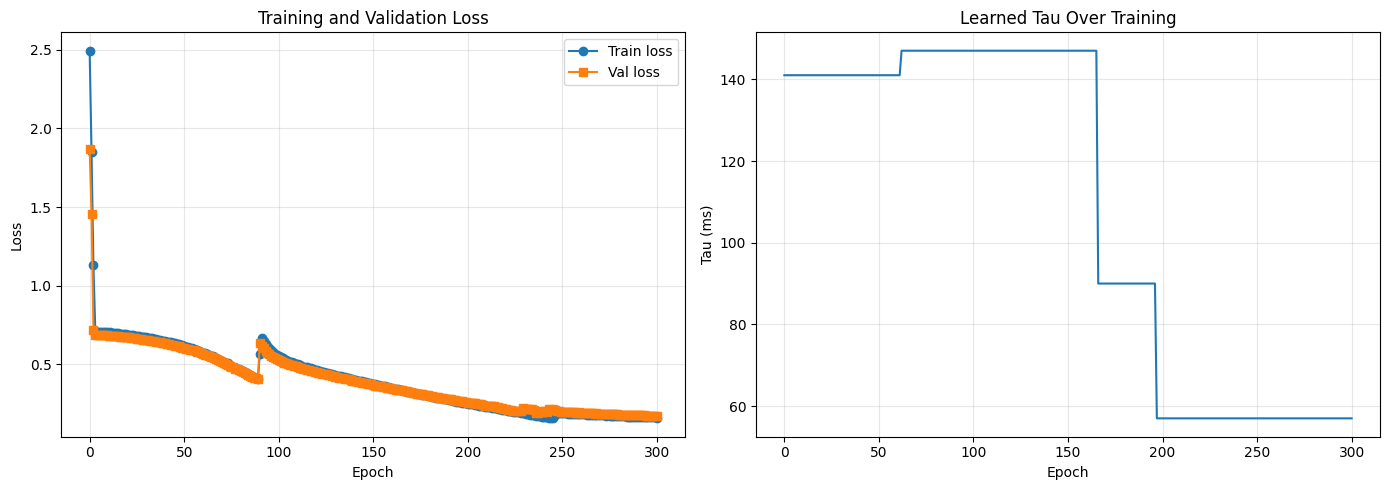


--- Training curves for f = 0.2 ---


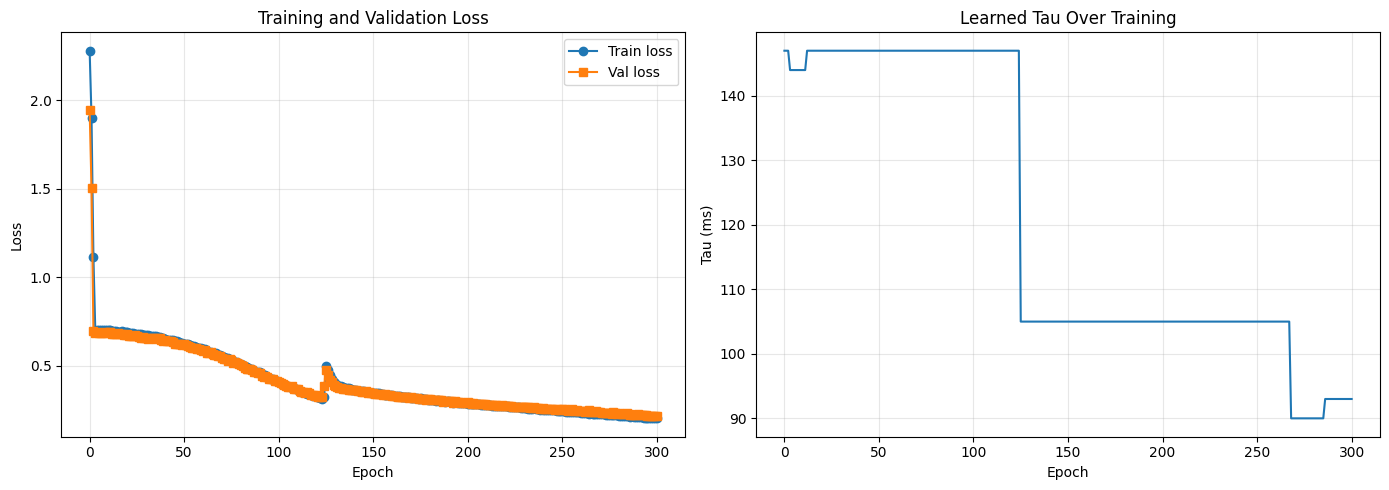


--- Training curves for f = 0.4 ---


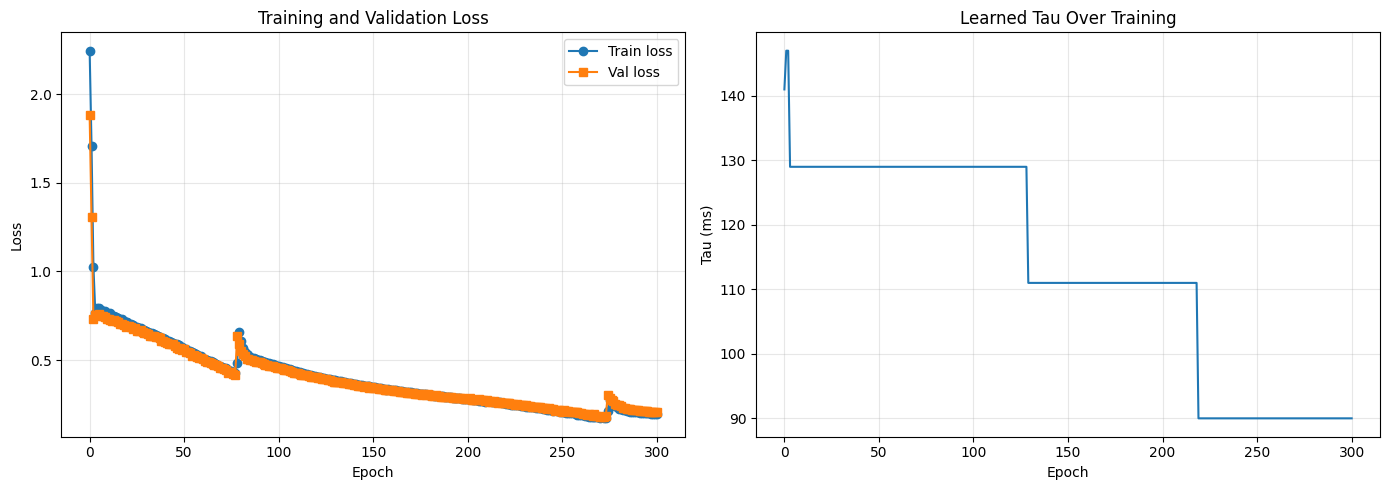


--- Training curves for f = 0.6 ---


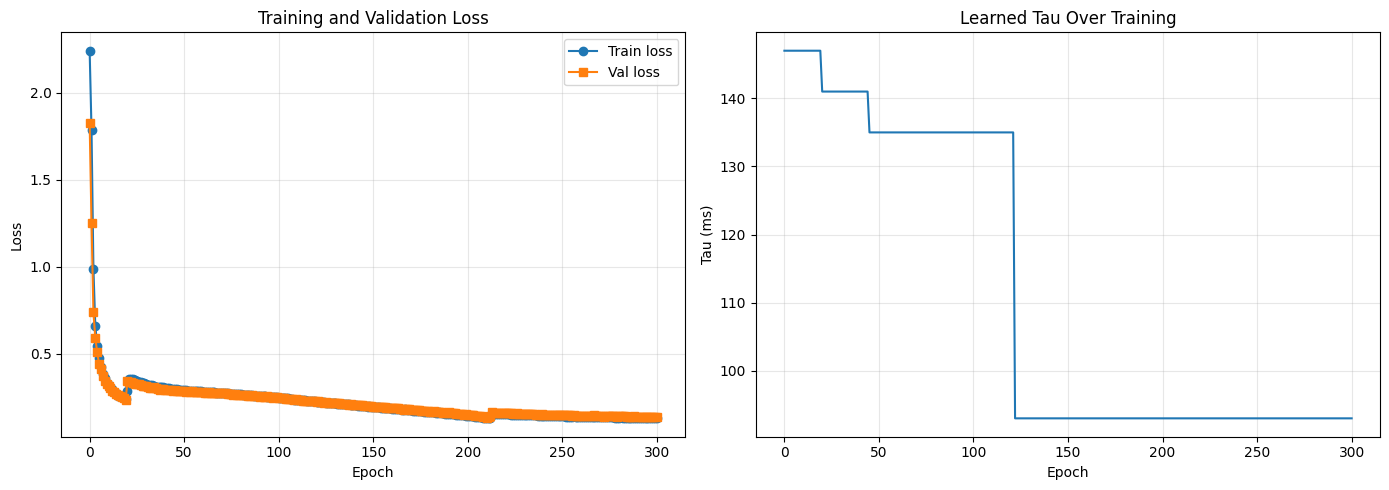


--- Training curves for f = 0.8 ---


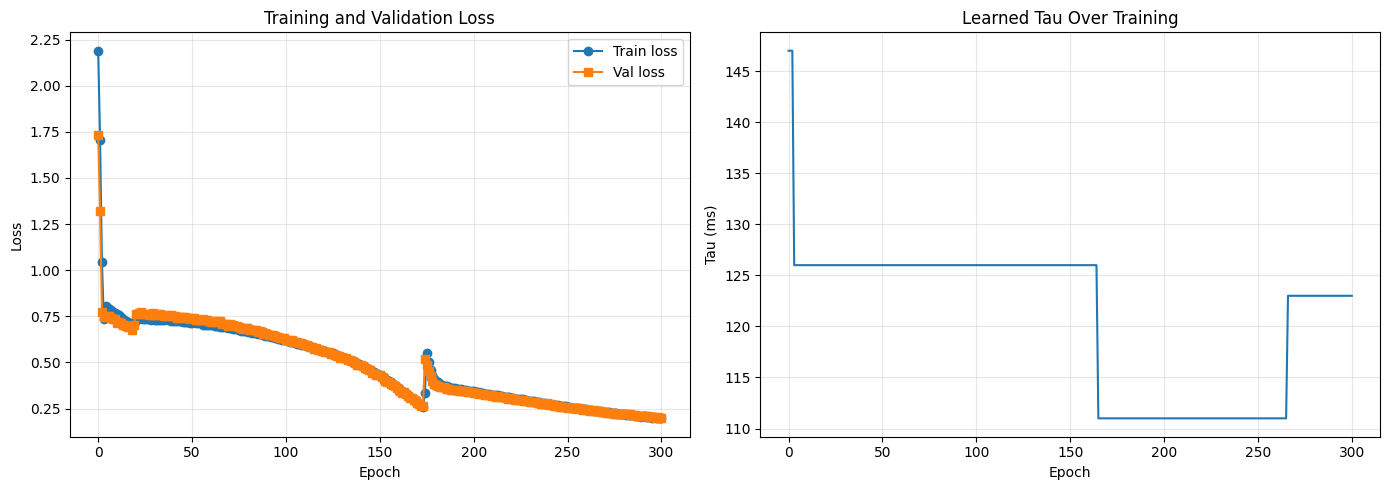


--- Training curves for f = 1.0 ---


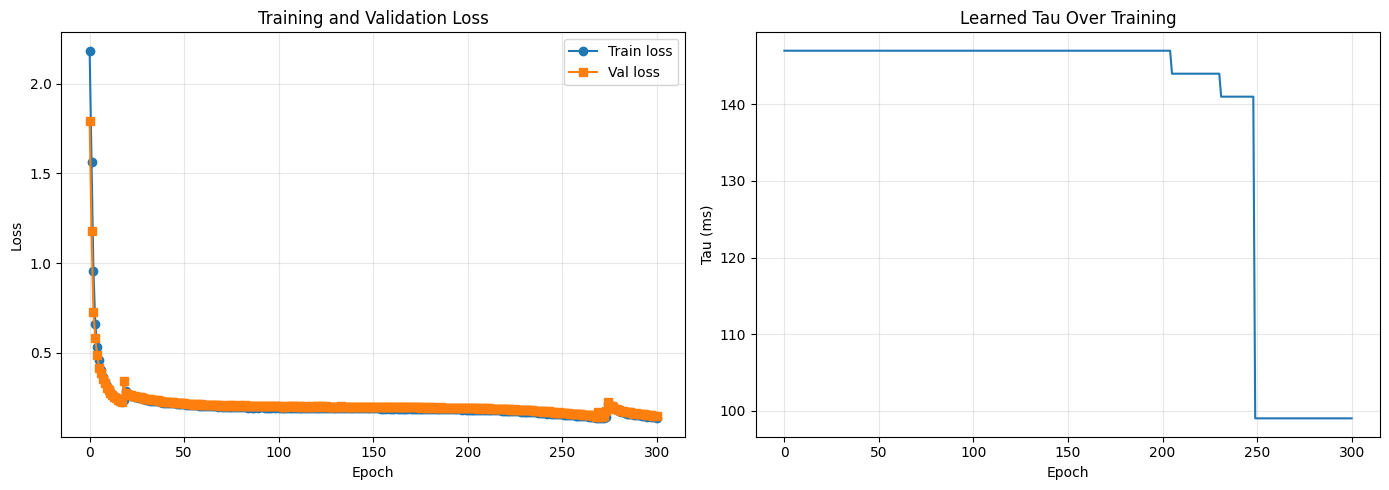

In [26]:
for f_val in F_VALUES:
    print(f"\n--- Training curves for f = {f_val} ---")
    plot_training_curves(training_logs[f_val])

## 12. Sweep Summary

Per-f accuracies (already collected during the train+eval loop above).

In [27]:
print("=== Train-at-f / Eval-at-f Summary (ISI, learnable tau) ===")
for f_val in F_VALUES:
    r = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {r['mean']:.4f} +/- {r['std']:.4f}")

=== Train-at-f / Eval-at-f Summary (ISI, learnable tau) ===
  f=0.0:  accuracy = 0.9722 +/- 0.0000
  f=0.2:  accuracy = 0.9574 +/- 0.0015
  f=0.4:  accuracy = 0.9580 +/- 0.0023
  f=0.6:  accuracy = 0.9593 +/- 0.0015
  f=0.8:  accuracy = 0.9463 +/- 0.0000
  f=1.0:  accuracy = 0.9556 +/- 0.0015


## 13. Plot Results

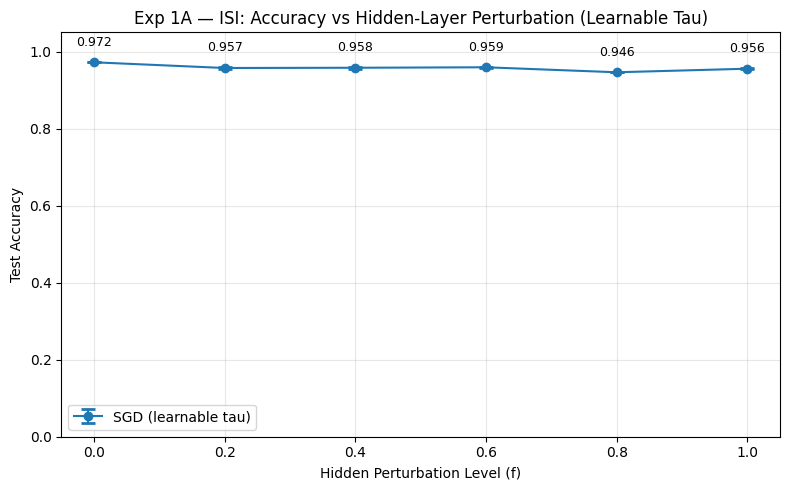

Figure saved to log/isi_tau_hidden_perturbation.png


In [28]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the sweep results to JSON for later comparison with the delay model
(isi_delay) and with the original input-perturbation baseline.

In [29]:
results_serialisable = {
    str(f_val): {
        "mean": float(data["mean"]),
        "std": float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

os.makedirs("log", exist_ok=True)
results_path = "log/isi_tau_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in tlog.items()
    }
    for f_val, tlog in training_logs.items()
}
log_path = "log/isi_tau_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

Results saved to log/isi_tau_hidden_perturbation_results.json
Training logs saved to log/isi_tau_training_log.json


## 15. Model Analysis

Print the learned tau value and weight statistics for inspection.

In [30]:
print("=== Learned Parameter Analysis (per f) ===")
for f_val in F_VALUES:
    net_f = trained_nets[f_val]
    tau_val = net_f.get_tau().item() / MS
    print(f"\n[f = {f_val}]")
    print(f"  Learned effective tau: {tau_val:.2f} ms")
    filter_weights = net_f.psp_filter.weight.data.squeeze().cpu().numpy()
    print(f"  PSP filter — max: {np.max(np.abs(filter_weights)):.4f}, "
          f"mean: {np.mean(filter_weights):.4f}")

=== Learned Parameter Analysis (per f) ===

[f = 0.0]
  Learned effective tau: 57.00 ms
  PSP filter — max: 1.1181, mean: 0.6628

[f = 0.2]
  Learned effective tau: 93.00 ms
  PSP filter — max: 0.9800, mean: 0.6986

[f = 0.4]
  Learned effective tau: 90.00 ms
  PSP filter — max: 1.0382, mean: 0.7184

[f = 0.6]
  Learned effective tau: 93.00 ms
  PSP filter — max: 1.1120, mean: 0.7432

[f = 0.8]
  Learned effective tau: 123.00 ms
  PSP filter — max: 1.0329, mean: 0.7098

[f = 1.0]
  Learned effective tau: 99.00 ms
  PSP filter — max: 1.0232, mean: 0.7405
